In [ ]:
# ! pip install -r requirements.txt

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("../data/loan_default.csv")
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [4]:
# To remove irrelevent columns
df = df.drop("LoanID",axis=1)

In [5]:
# Clean binary/ordinal columns
for col in ['Education', 'HasCoSigner', 'HasMortgage', 'HasDependents']:
    df[col] = df[col].astype(str).str.strip()

In [6]:
# Save cleaned df
import joblib
joblib.dump(df, "../src/cleaned_loan_df.pkl")

['../src/cleaned_loan_df.pkl']

In [5]:
df.info()
# there is no null value in all columns
# We can set datatypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Age             255347 non-null  int64  
 1   Income          255347 non-null  int64  
 2   LoanAmount      255347 non-null  int64  
 3   CreditScore     255347 non-null  int64  
 4   MonthsEmployed  255347 non-null  int64  
 5   NumCreditLines  255347 non-null  int64  
 6   InterestRate    255347 non-null  float64
 7   LoanTerm        255347 non-null  int64  
 8   DTIRatio        255347 non-null  float64
 9   Education       255347 non-null  object 
 10  EmploymentType  255347 non-null  object 
 11  MaritalStatus   255347 non-null  object 
 12  HasMortgage     255347 non-null  object 
 13  HasDependents   255347 non-null  object 
 14  LoanPurpose     255347 non-null  object 
 15  HasCoSigner     255347 non-null  object 
 16  Default         255347 non-null  int64  
dtypes: float64

In [11]:
# only applicable on numerical columns
df.describe()
# All numerical columns has almost same median and mean, its mean there is symmetric distribution

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [4]:
df.Default.value_counts(normalize=True)*100
# Output column is imbalance,  yes = 88.3 %, No = 11.6 %
# We have to apply imbalanced data techniques

Default
0    88.387175
1    11.612825
Name: proportion, dtype: float64

In [ ]:
df.duplicated().sum() # Ther is no duplicate value in dataset

np.int64(0)

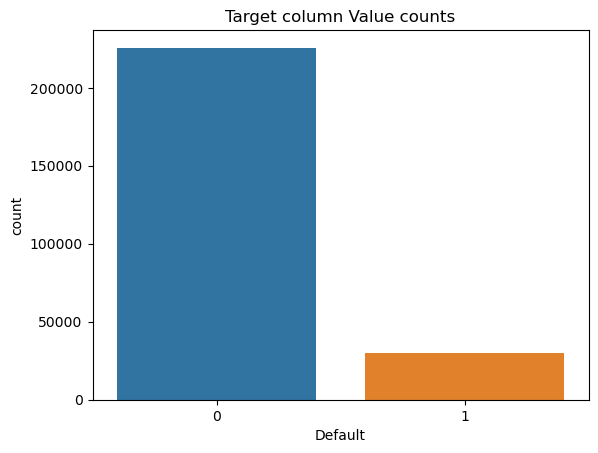

In [9]:
# Class distribution
sns.countplot(x='Default', data=df)
plt.title("Target column Value counts")
plt.savefig("../output/Target_value_count.png")

In [ ]:
categorical_cols = df[[ 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']]
# # categorical_cols = ['Education', 'EmploymentType', 'MaritalStatus', 'LoanPurpose']
# for col in categorical_cols:
#     sns.countplot(y=col, data=df)
#     plt.show()
import matplotlib.pyplot as plt
import seaborn as sns

# categorical_cols = ['Education', 'EmploymentType', 'MaritalStatus', 'LoanPurpose']

# Set up horizontal layout
fig, axes = plt.subplots(1, len(categorical_cols), figsize=(18, 4))

for i, col in enumerate(categorical_cols):
    sns.countplot(y=col, data=df, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("Count")

plt.tight_layout()
plt.show()

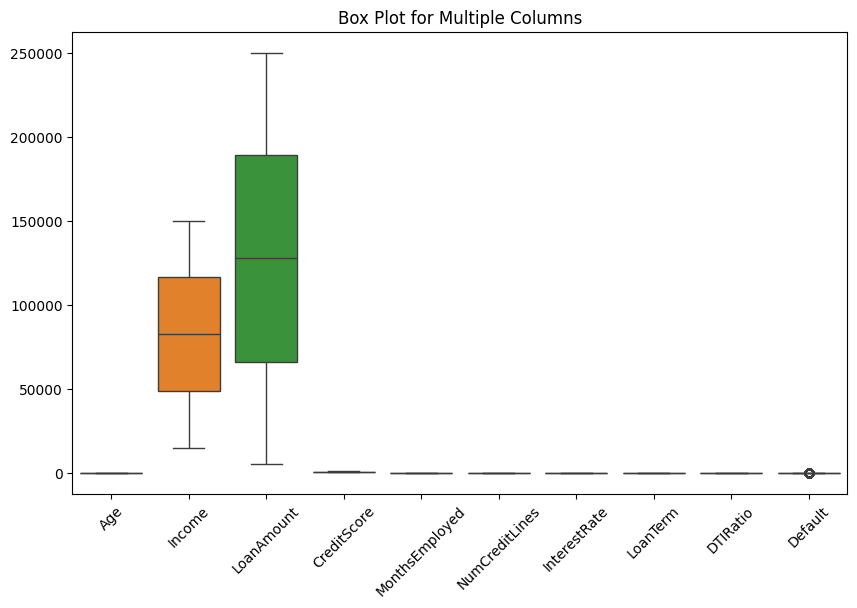

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[numerical_col])
plt.title("Box Plot for Multiple Columns")
plt.xticks(rotation=45)  # Rotate x-axis labels if needed
plt.show()
# There is problem in columns, we check it by value_counts

In [29]:
for col in numerical_col:
    print(col, " : ",df[col].kurt())

Age  :  -1.1984306327090095
Income  :  -1.198360926931816
LoanAmount  :  -1.2036798812613259
CreditScore  :  -1.200301814502096
MonthsEmployed  :  -1.1996324941634309
NumCreditLines  :  -1.3576713962415219
InterestRate  :  -1.1971672237742688
LoanTerm  :  -1.2998954478104605
DTIRatio  :  -1.199674818304813
Default  :  3.7426518315773514


<Axes: xlabel='Age', ylabel='Density'>

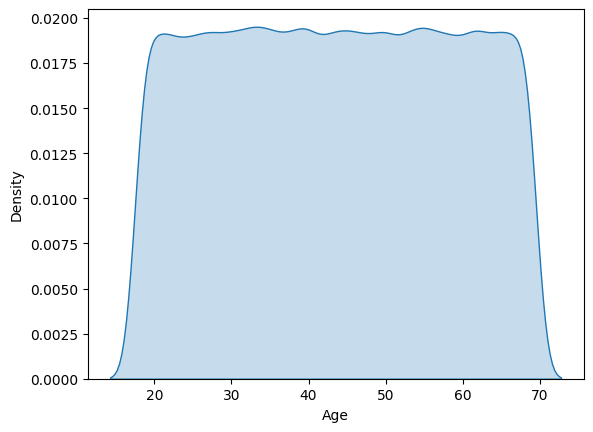

In [34]:
plt.Figure(figsize=(10,8))
sns.kdeplot(df.Age, fill=True)
# sns.kdeplot(df.LoanAmount, fill=True)

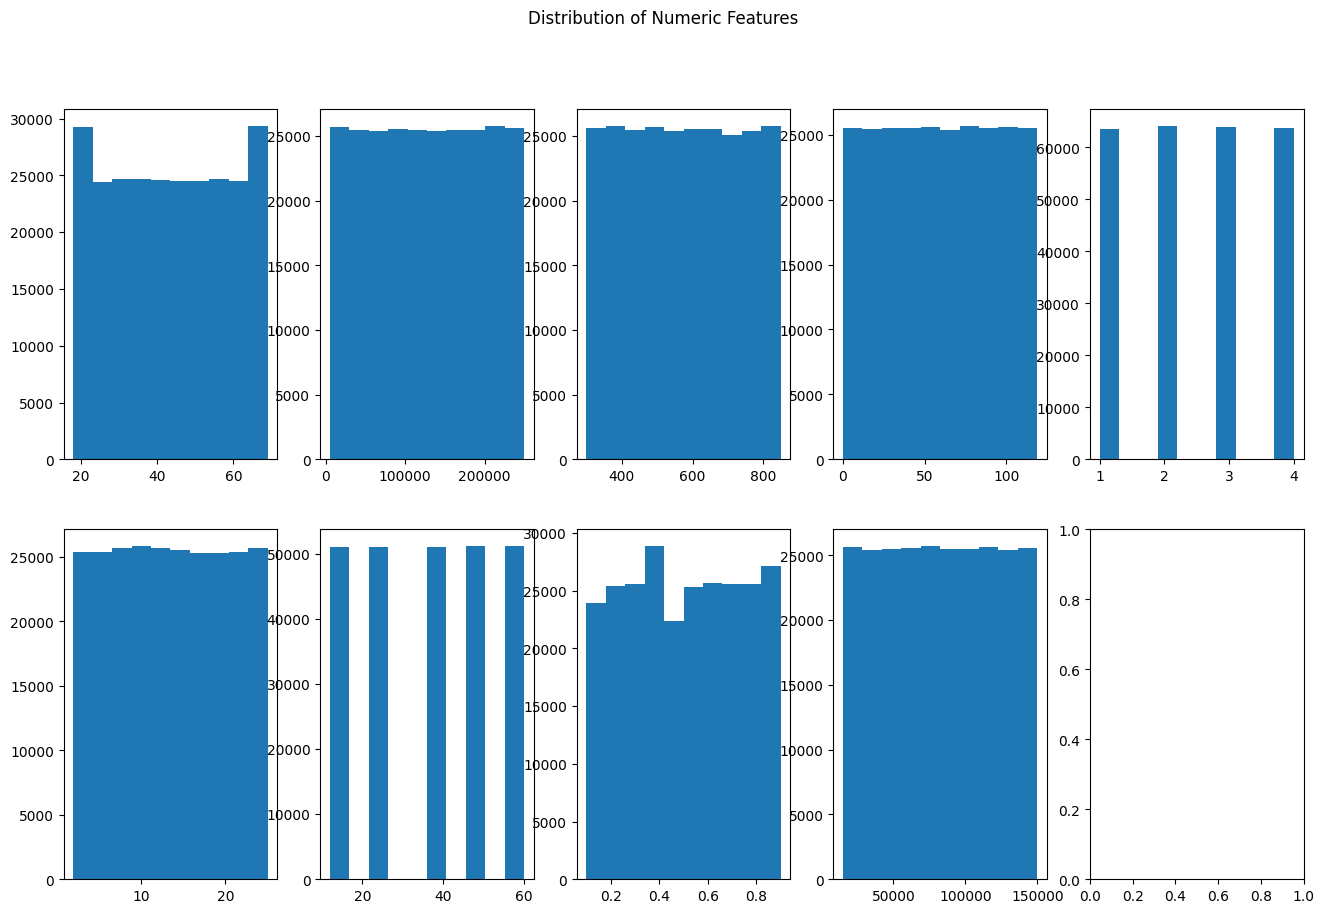

In [7]:
fig, ax = plt.subplots(nrows=2, ncols=5, figsize=(16,10))
fig.suptitle("Distribution of Numeric Features")
ax[0,0].hist(df.Age)
ax[0,1].hist(df.LoanAmount)
ax[0,2].hist(df.CreditScore)
ax[0,3].hist(df.MonthsEmployed)
ax[0,4].hist(df.NumCreditLines)
ax[1,0].hist(df.InterestRate)
ax[1,1].hist(df.LoanTerm)
ax[1,2].hist(df.DTIRatio)
ax[1,3].hist(df.Income)
plt.show()
# plt.savefig("../output/numerical_features_distribution.png", dpi=300, bbox_inches='tight')

In [47]:
df.NumCreditLines.value_counts()

NumCreditLines
2    64130
3    63834
4    63829
1    63554
Name: count, dtype: int64

In [49]:
df.LoanTerm.value_counts()

LoanTerm
48    51166
60    51154
36    51061
24    51009
12    50957
Name: count, dtype: int64

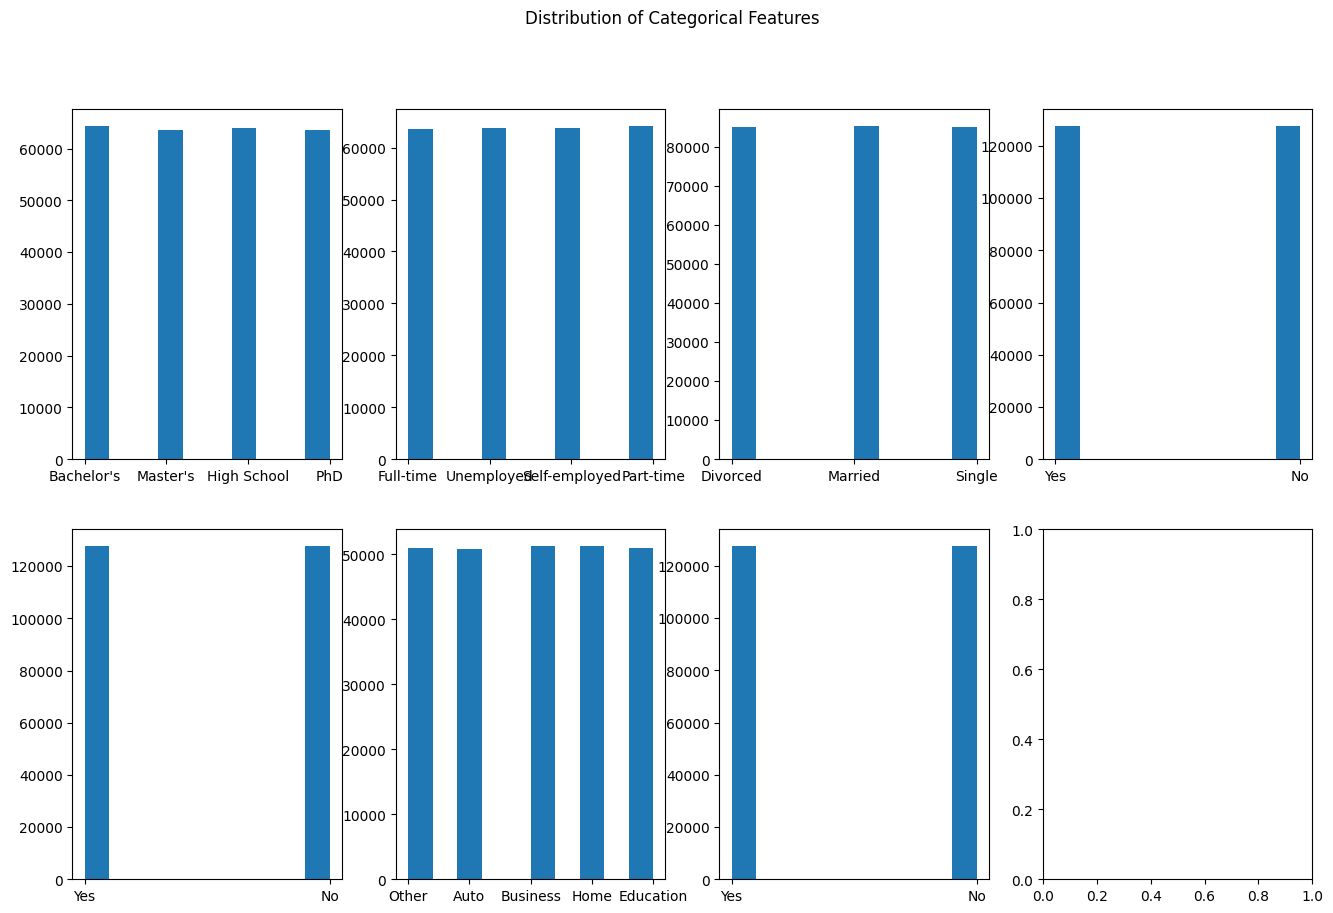

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(16,10))
fig.suptitle("Distribution of Categorical Features")
ax[0,0].hist(df.Education)
ax[0,1].hist(df.EmploymentType)
ax[0,2].hist(df.MaritalStatus)
ax[0,3].hist(df.HasMortgage)
ax[1,0].hist(df.HasDependents)
ax[1,1].hist(df.LoanPurpose)
ax[1,2].hist(df.HasCoSigner)
plt.show()
# plt.savefig("../output/categorical_features_distribution.png", dpi=300, bbox_inches='tight')